# Compost AI: USAII Hackathon Project

Compost AI is an AI-Powered Smart Bin designed to reduce food waste in school cafeterias. It is a component of ***SchoolPrint***, which is a suite of edge AI toolds design to help reduce a school's environmental footprint. This notebook contains the dataset, code and results of training Compost AI's waste classification model. 

## 0. Import Libraries

In [29]:
import os
import math
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## 1. Data Preprocessing
### 1.1. Load the Waste Classification Dataset

To train our **Stage A: Base Waste Classifier**,we will be using the [Recyclable and Household Waste Classification Dataset](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) on Kaggle. We're using this dataset for a couple of reasons:

1. It's a comprehensive dataset with over **15,000 images** across **30 classes** that covers wide range of categories including: `Plastic`, `Paper`, `Cardboard`, `Glass`, `Metal`, `Organic Waste` and `Textiles`.

2. The dataset offers 500 images per class, which is further split into 2 directories. The `default` folder offers a studio-image like representation of the waste item and the `real_world`folder offers images of the waste item in a real-world scenario. 

In [5]:
dataset_path = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
if (dataset_path.exists()):
    print("The Recyclable and Household Waste Dataset was loaded successfully")

The Recyclable and Household Waste Dataset was loaded successfully


### 1.2 Set the Random Seed

We fix a random seed so that every split and shuffle is reproducible, so if someone else is running this notebook they recieve the same results.

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1.3 Map each Class of Waste to a Disposal Pathway

Each of the 30 classes needs to be mapped to one of four disposal pathways: `garbage`, `recycling` and `compost`. The code cell below contains a Python dictionary of each class (key) and their disposal pathway (value). 

**Note:** The United States has over 19,000 different muncipalities and each municipality has different guidelines regarding how different items of waste should be disposed. To keep things simple, we will be using the waste disposal guidelines for the City of Phoenix (the author's hometown).

In [7]:
DISPOSAL_MAP = {
    # Recycling: 17 classes
    "aerosol_cans":            "recycling",
    "aluminum_soda_cans":      "recycling",
    "aluminum_food_cans":      "recycling",
    "steel_food_cans":         "recycling",
    "cardboard_boxes":         "recycling",
    "cardboard_packaging":     "recycling",
    "glass_beverage_bottles":  "recycling",
    "glass_cosmetic_containers": "recycling",
    "glass_food_jars":         "recycling",
    "plastic_detergent_bottles": "recycling",
    "plastic_soda_bottles":    "recycling",
    "plastic_water_bottles":   "recycling",
    "plastic_food_containers": "recycling",
    "newspaper":               "recycling",
    "office_paper":            "recycling",
    "magazines":               "recycling",
    "paper_cups":              "recycling",
    
    # Garbage: 9 classes
    "styrofoam_cups":            "garbage",
    "styrofoam_food_containers": "garbage",
    "plastic_shopping_bags":     "garbage",
    "plastic_straws":            "garbage",
    "plastic_cup_lids":          "garbage",
    "plastic_trash_bags":        "garbage",
    "disposable_plastic_cutlery": "garbage",
    "clothing":                  "garbage",
    "shoes":                     "garbage",
    
    # Compost: 4 classes
    "food_waste":        "compost",
    "coffee_grounds":    "compost",
    "eggshells":         "compost",
    "tea_bags":          "compost",
}

### 1.4 Visual Audit of Dataset

We will print 9 random images from our dataset in a 3x3 dataset, so we can manually check that the labels are correct and that the image quality is up to standard.

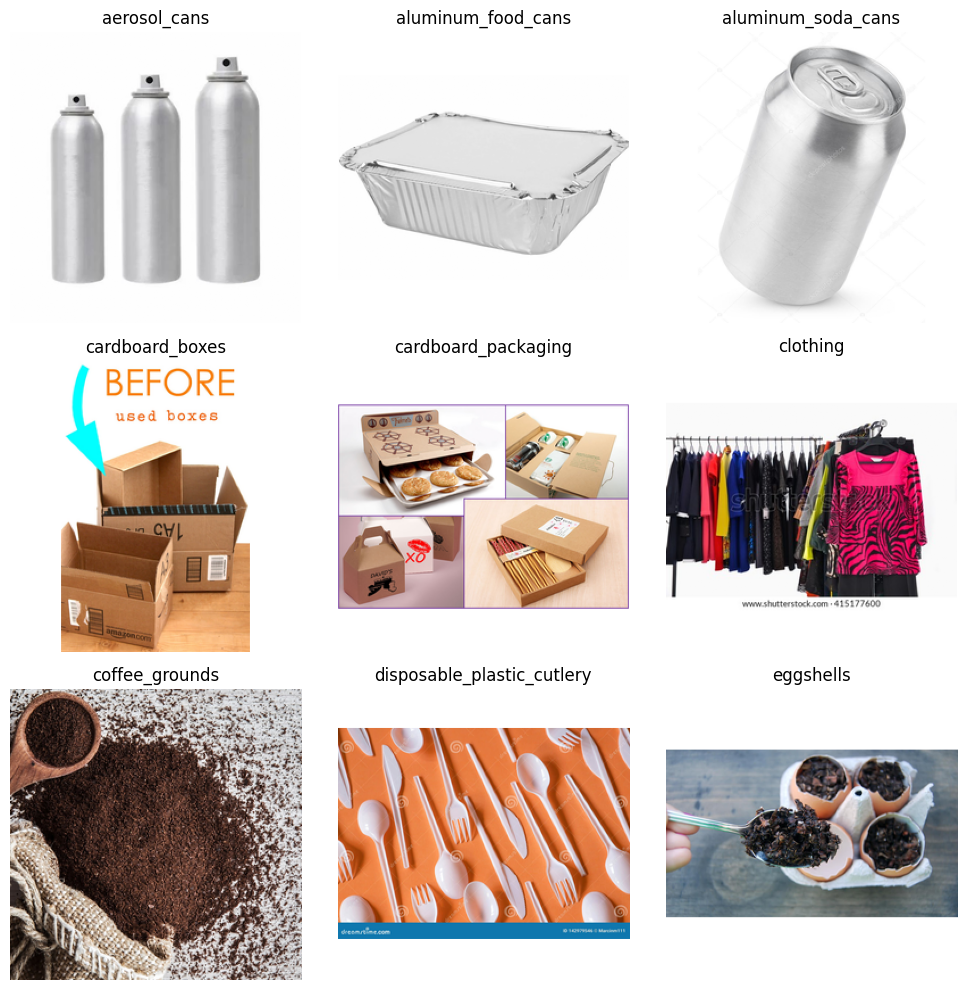

In [8]:
# Initalize an array of 9 random images from the database
class_dirs = sorted([d for d in dataset_path.iterdir() if d.is_dir()])[:9]
image_files = [(random.choice(list(d.glob("**/*.png"))), d.name) for d in class_dirs]

# Set up a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Loop through each image in the array and display each image on the plot
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(image_files[i][0])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(image_files[i][1]) # Truncate title length
plt.tight_layout()
plt.show()

### 1.5 Display Class Distribution

Before we begin training, we have to check the sample size of each class. This helps us determine class weights to account for over or underepresentation between certain classes. In the code cell below, we create a bar chart that helps us visualize the sample size of images for each class. Additionally, each class's bar is colored based on its disposal pathway. This helps us identify which classes of waste belong in which disposal pathway easily.

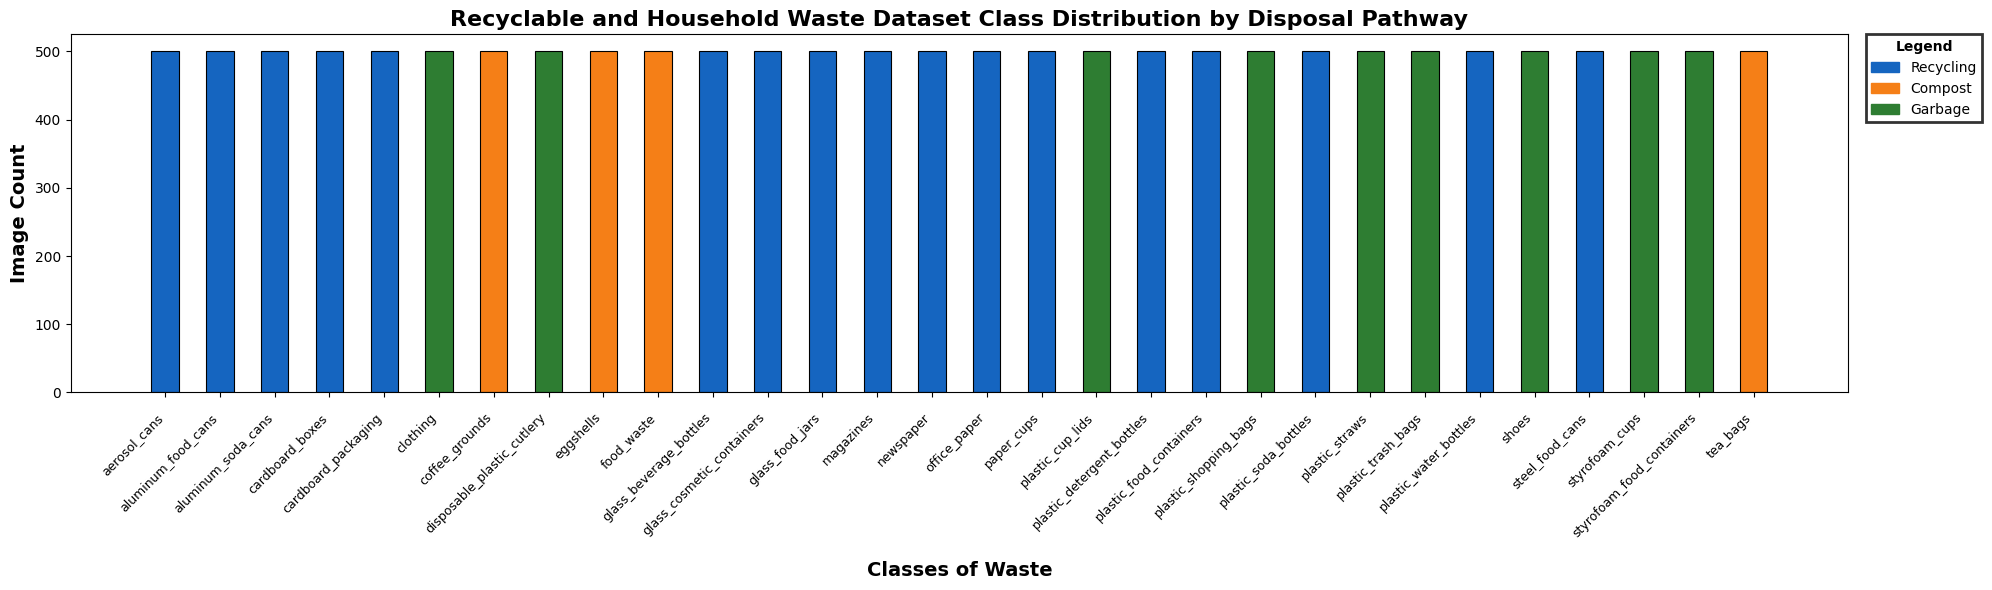

In [9]:
# Define dataset bar chart audit directory
dataset_bar_chart_audit_path = Path("/kaggle/working/audit")
dataset_bar_chart_audit_path.mkdir(parents=True, exist_ok=True)

# Build a DataFrame of class names, image counts, and disposal pathways
rows = []
for class_dir in sorted(dataset_path.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob("**/*.png")))
        pathway = DISPOSAL_MAP.get(class_dir.name, "UNMAPPED")
        rows.append({"class": class_dir.name, "count": count, "pathway": pathway})

df = pd.DataFrame(rows)

# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'recycling': '#1565C0',
    'compost':   '#F57F17',
    'garbage':   '#2E7D32',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#B71C1C') for p in df['pathway']],
       edgecolor='black', linewidth=0.8)
ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)
ax.set_xlabel('Classes of Waste', fontweight='bold', fontsize=14, labelpad=15)
ax.set_ylabel('Image Count', fontweight='bold', fontsize=14)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=16)
legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to Waste Classification Dataset Audit
plt.tight_layout()
plt.savefig(dataset_bar_chart_audit_path / 'class_distribution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart is well balanced: every class has roughly the same number of images and there are no missing or unmapped classes. It's important to note that two classes: `carboard_boxes` and `carboard_packaging` might contain similar looking items, which may cause some confusion for our model during training. 

### 1.6 Split Dataset into Train/Val/Test
We will now split the data into three paths: **train (70%)**, **validation (15%)**, and **test (15%)**. The images in the train path will be used to train our waste classification model, the validation datset will be used to asses the results of the model after completing an epoch of training and the test dataset will be used to evaluate the results of the model after all training is complete.

In [10]:
# Collect all image paths and integer labels from the dataset
all_images, all_labels = [], []
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_dir in sorted(dataset_path.iterdir()):
    if class_dir.is_dir():
        paths = list(class_dir.glob("**/*.png"))
        all_images.extend([str(p) for p in paths])
        all_labels.extend([class_to_idx[class_dir.name]] * len(paths))

# Split into 70% train, 15% val, 15% test — stratified to keep class balance
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Images in Training Dataset: {len(X_train)} \nImages in Validation Dataset: {len(X_val)} \nImages in Validation Dataset: {len(X_test)}")

Images in Training Dataset: 10500 
Images in Validation Dataset: 2250 
Images in Validation Dataset: 2250


## 2. Train the Waste Classification Model

### 2.1 Load the Split Datasets onto TensorFlow
Now we will load the three split directories into TensorFlow datasets. Each image is resized to 224 by 224 and grouped into batches of 32. Additionally, we store images into memory after the first epoch so we don't have to load them every time and load the next batch on the CPU while the GPU is training to save resources.

In [11]:
# Define Image and Batch Sizes
AUTOTUNE   = tf.data.AUTOTUNE
IMG_SIZE   = 224
BATCH_SIZE = 32

# Build class name list and label index from dataset directory
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {class_names}")

# Load, decode, resize and one-hot encode a single image from disk
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

# Build a cached tf.data.Dataset pipeline from sklearn path/label lists
def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), list(labels)))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Training Dataset (train)
train_ds = make_dataset(X_train, y_train, shuffle=True)

# Validation Dataset (val)
val_ds   = make_dataset(X_val, y_val)

# Test Dataset (test)
test_ds  = make_dataset(X_test, y_test)

# Separate test sets for default and real_world images
test_pairs            = list(zip(X_test, y_test))
test_default_pairs    = [(p, l) for p, l in test_pairs if 'default'    in p]
test_real_world_pairs = [(p, l) for p, l in test_pairs if 'real_world' in p]

X_test_default,    y_test_default    = zip(*test_default_pairs)
X_test_real_world, y_test_real_world = zip(*test_real_world_pairs)

# Test Dataset of Default Images - test_default
test_default_ds    = make_dataset(X_test_default,    y_test_default)

# Test Dataset of Real World Images - test_real_world
test_real_world_ds = make_dataset(X_test_real_world, y_test_real_world)

Number of classes: 30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']


I0000 00:00:1781644635.602545      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### 2.2 Build the Data Augmentation Pipeline
Data augmentation prevents the model from memorising specific orientations or lighting conditions. This prevents the model from overfitting, where it memorizes training images rather than learning genuine patterns among images of the same class. We will use 6 data augmentation techniques for training our model:

| Technique | What it does |
|---|---|
| `RandomRotation(30/360)` | Rotates the image up to ±30° |
| `RandomZoom(0.2)` | Zooms in or out by up to 20% |
| `RandomTranslation(0.15, 0.15)` | Shifts the image up to 15% in any direction |
| `RandomFlip("horizontal_and_vertical")` | Randomly mirrors the image left-right and/or top-bottom |
| `RandomBrightness(0.15)` | Randomly lightens or darkens the image by up to 15% |
| `RandomContrast(0.15)` | Randomly increases or decreases contrast by up to 15% |

In [17]:
# Data Augmentation Pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=30/360),            # Rotates up to +/- 30 degrees
    layers.RandomZoom(height_factor=0.2),            # Zooms in or out up to 20%
    layers.RandomTranslation(height_factor=0.15,
                             width_factor=0.15),     # Shifts up to 15% in any direction
    layers.RandomFlip("horizontal_and_vertical"),    # Mirrors left-right and top-bottom
    layers.RandomBrightness(factor=0.15),            # Lightens or darkens by up to 15%
    layers.RandomContrast(factor=0.15),              # Increases or decreases contrast by up to 15%
], name="augmentation")

### 2.3 Build the Waste Classification Model
Now that we have an augmentation pipeline in place, we can build the Waste Classification Model, which is a transfer learning model built on top of **EfficientNet-B0**, a pretrained convolutional neural network that has already learned how to recognise low level visual features (edges, colors, textures, shapes) from millions of ImageNet photos. By starting from those weights instead of training from scratch, our model picks up waste-specific patterns much faster and with far less data than it would otherwise need.

The backbone is frozen during the first phase of training so that only the classification head learns. The head takes the backbone's feature map, pools it down to a single vector, runs it through a dropout-protected 256-unit dense layer with L2 regularization, and finishes with a softmax over the 30 waste classes. Dropout and L2 are both there to discourage overfitting on the smaller waste dataset.

In [18]:
# Define Cosine Decay until the end of learning rate to smooth accuracy dip in Phase 2
class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, start_lr, peak_lr, end_lr, warmup_steps, total_steps):
        super().__init__()
        self.start_lr     = float(start_lr)
        self.peak_lr      = float(peak_lr)
        self.end_lr       = float(end_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.start_lr + (self.peak_lr - self.start_lr) * (step / self.warmup_steps)
        decay_progress = (step - self.warmup_steps) / max(self.total_steps - self.warmup_steps, 1.0)
        decay_progress = tf.clip_by_value(decay_progress, 0.0, 1.0)
        cosine = 0.5 * (1.0 + tf.cos(math.pi * decay_progress))
        decayed_lr = self.end_lr + (self.peak_lr - self.end_lr) * cosine
        return tf.where(step < self.warmup_steps, warmup_lr, decayed_lr)
    def get_config(self):
        return {
            "start_lr":     self.start_lr,
            "peak_lr":      self.peak_lr,
            "end_lr":       self.end_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps":  self.total_steps,
        }

# Set every BatchNormalization Layer to non-trainable to avoid catastrophic forgetting
def freeze_batchnorm(model):
    """Set every BatchNormalization layer to non-trainable.
    Keeps backbone feature statistics stable during fine-tuning so the loss
    curve climbs smoothly rather than dipping after unfreezing.
    """
    for layer in model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

# Built the model on EfficientNet-B0 Architecture using transfer learning
def build_model(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)  # Apply data augmentation pipeline
    base_model = EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model._name = "efficientnetb0_backbone"
    base_model.trainable = False  # Frozen for Phase 1; Phase 2 will unfreeze the top half
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="swish",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    model = Model(inputs, outputs, name="compost_ai")
    return model, base_model

# Print summary of the model architecture
model, base_model = build_model(NUM_CLASSES)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "compost_ai"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,390,337 (16.75 MB)

 Trainable params: 338,206 (1.29 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### 2.4 Define Training Callbacks
Before we begintraining, we need to define the callbacks that monitor the training run and adjust it on the fly. We train our waste classification model in two phases (Phase 1 freezes the backbone and warms up the head, Phase 2 fine-tunes the top half of the backbone), and each phase needs a slightly different set of callbacks. The table below summarizes what each one does and where it is used.

| Callback | Where | Monitors | What It Does |
|-|-|-|-|
| `ModelCheckpoint` | both phases | `val_accuracy` | Saves the best weights to disk whenever validation accuracy improves |
| `EarlyStopping` | both phases | `val_accuracy` | Stops training after several epochs of no improvement and rolls the model back to the best weights it has seen |
| `ReduceLROnPlateau` | Phase 1 only | `val_loss` | Halves the learning rate when validation loss stalls, giving the model a finer step to escape the plateau |
| `WarmupCosineSchedule` | Phase 2 only | step count | Linear warmup to a small peak learning rate, then cosine decay to a near-zero floor (defined as a helper class in section 2.3) |

In [20]:
MODELS_PATH = Path("/kaggle/working/models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Saves the weights of the epoch with the best val accuracy
checkpoint_cb = ModelCheckpoint(
    str(MODELS_PATH / "compost_ai_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

### 2.5 Train the Model
Now we can train the model. The training happens in two phases. In Phase 1, the EfficientNet-B0 backbone stays frozen and only the new classification head learns; this is fast because almost all the weights are locked, and it gets the new head into a reasonable starting point without disturbing the pretrained features.

In Phase 2, we unfreeze the top half of the backbone and let it adapt slightly to waste imagery using a warmup-cosine learning rate that peaks at 1e-4. Every BatchNormalization layer in the backbone stays in inference mode for Phase 2 to stop its running statistics from drifting on the small fine-tune batches.

In [21]:
#=========
# Phase 1
#=========


# Freeze the backbone and only train the classification head
print("Phase 1 - warming up head (backbone frozen)")
base_model.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)
PHASE1_EPOCHS = 15
history_p1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        checkpoint_cb,
        EarlyStopping(monitor="val_accuracy", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-4, verbose=1),
    ],
    verbose=1,
)
phase1_epochs_run = len(history_p1.history["accuracy"])

#=========
# Phase 2
#=========

# Unfreezes the bottom of the backbone to learn waste specific features
print("\nPhase 2 - fine-tuning top half of backbone (BN frozen, cosine LR)")
base_model.trainable = True
total_layers  = len(base_model.layers)
unfreeze_from = total_layers // 2
for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False   # Bottom half stays frozen
freeze_batchnorm(base_model)  # Every BN layer locked
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"  unfrozen backbone layers: {trainable_count} of {total_layers}")

PHASE2_EPOCHS   = 25
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
total_steps     = int(steps_per_epoch) * PHASE2_EPOCHS
warmup_steps    = int(steps_per_epoch) * 3  # 3-epoch warmup before cosine decay kicks in
lr_schedule = WarmupCosineSchedule(
    start_lr=1e-6,
    peak_lr=1e-4,
    end_lr=1e-6,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)
history_p2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        checkpoint_cb,
        EarlyStopping(monitor="val_accuracy", patience=8,
                      restore_best_weights=True, verbose=1),
    ],
    verbose=1,
)


# Merge Phase 1 and Phase 2 Training Histories
class _History:
    pass
history = _History()
shared_keys = history_p1.history.keys() & history_p2.history.keys()
history.history = {
    k: history_p1.history[k] + history_p2.history[k]
    for k in shared_keys
}

# Print training summary
print(f"\nPhase 1 ran {phase1_epochs_run} epochs; "
      f"Phase 2 ran {len(history_p2.history['accuracy'])} epochs")
print(f"Best checkpoint saved to: {MODELS_PATH / 'compost_ai_best.keras'}")

Phase 1 - warming up head (backbone frozen)
Epoch 1/15


E0000 00:00:1781644767.256733      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/compost_ai_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781644772.655940     165 cuda_dnn.cc:529] Loaded cuDNN version 91002


328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4327 - loss: 2.5405
Epoch 1: val_accuracy improved from None to 0.75289, saving model to /kaggle/working/models/compost_ai_best.keras

Epoch 1: finished saving model to /kaggle/working/models/compost_ai_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 58s 128ms/step - accuracy: 0.5412 - loss: 2.1418 - val_accuracy: 0.7529 - val_loss: 1.4015 - learning_rate: 0.0010
Epoch 2/15
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6614 - loss: 1.7030
Epoch 2: val_accuracy improved from 0.75289 to 0.79067, saving model to /kaggle/working/models/compost_ai_best.keras

Epoch 2: finished saving model to /kaggle/working/models/compost_ai_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - accuracy: 0.6646 - loss: 1.6893 - val_accuracy: 0.7907 - val_loss: 1.3636 - learning_rate: 0.0010
Epoch 3/15
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7051 - loss: 1.5788
Epoch 3: val_accuracy improved from 0.79067 to 0.81022, saving model to 

E0000 00:00:1781645149.725489      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/compost_ai_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8280 - loss: 1.3021
Epoch 1: val_accuracy improved from 0.84000 to 0.84844, saving model to /kaggle/working/models/compost_ai_best.keras

Epoch 1: finished saving model to /kaggle/working/models/compost_ai_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 52s 108ms/step - accuracy: 0.8381 - loss: 1.2677 - val_accuracy: 0.8484 - val_loss: 1.2166
Epoch 2/25
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8463 - loss: 1.2516
Epoch 2: val_accuracy improved from 0.84844 to 0.85511, saving model to /kaggle/working/models/compost_ai_best.keras

Epoch 2: finished saving model to /kaggle/working/models/compost_ai_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 33s 99ms/step - accuracy: 0.8561 - loss: 1.2226 - val_accuracy: 0.8551 - val_loss: 1.1965
Epoch 3/25
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8627 - loss: 1.2088
Epoch 3: val_accuracy did not improve from 0.85511
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 96ms/step - accuracy: 0.8654 - lo

## 3. Evaluate the Waste Classification Model

### 3.1 Plot Training v Validation Error Metrics
With training complete, he first thing we want to check are the training and validation accuracy and loss curves over time. These curves are a quick sanity check before we evaluate on the test set. The dashed grey vertical line marks the switch from Phase 1 (frozen backbone) to Phase 2 (top half of backbone fine-tuned). With BatchNorm frozen during Phase 2, the curve should climb smoothly through the transition rather than dipping. A widening gap between the train and validation curves at the end of training would be a sign of overfitting.

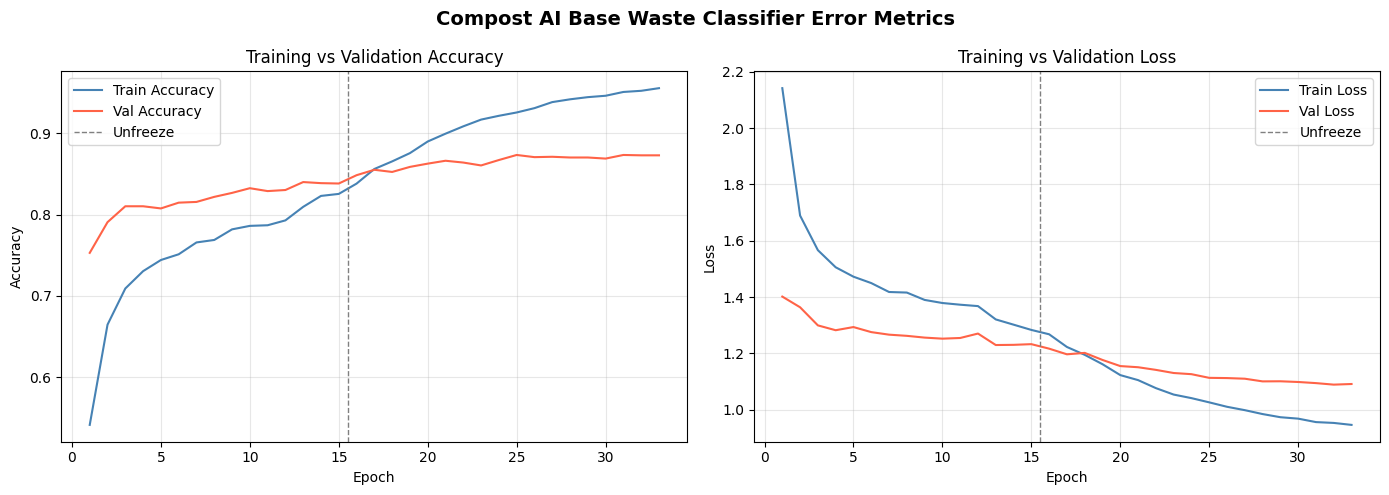

In [22]:
# Print Accuracy and Loss Curves
STAGE_A_RESULTS_PATH = Path("/kaggle/working/results")
STAGE_A_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

epochs = range(1, len(history.history["accuracy"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs, history.history["accuracy"],     label="Train Accuracy", color="steelblue")
ax1.plot(epochs, history.history["val_accuracy"], label="Val Accuracy",   color="tomato")
ax1.axvline(phase1_epochs_run + 0.5, color="grey", linestyle="--", linewidth=1, label="Unfreeze")
ax1.set_title("Training vs Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs, history.history["loss"],     label="Train Loss", color="steelblue")
ax2.plot(epochs, history.history["val_loss"], label="Val Loss",   color="tomato")
ax2.axvline(phase1_epochs_run + 0.5, color="grey", linestyle="--", linewidth=1, label="Unfreeze")
ax2.set_title("Training vs Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.suptitle("Compost AI Base Waste Classifier Error Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / "error_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Evaluate the Model on the Test Set
Now we run the best model checkpoint on the held-out test set and report per-class accuracy, precision, recall, and F1 score for each of the 30 classes. The classes are sorted by accuracy in descending order so the strongest and weakest performers are easy to spot. The macro average at the bottom gives the overall picture across all 30 classes.

In [26]:
# Load the best checkpoint with compile=False so WarmupCosineSchedule does not need to be reconstructed for inference
best_model = tf.keras.models.load_model(MODELS_PATH / 'compost_ai_best.keras', compile=False)

# Run predictions on full test set
all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot labels to integer class indices
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Build the confusion matrix and pull per-class accuracy off the diagonal
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
sorted_indices     = np.argsort(per_class_accuracy)[::-1]  # Descending so top performers are at the top
report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Print classification report sorted by per-class accuracy in descending order
print("Compost AI Classification Report")
print("=" * 75)
print(f"{'Class':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 75)
for i in sorted_indices:
    name = class_names[i]
    acc  = per_class_accuracy[i]
    p    = report[name]['precision']
    r    = report[name]['recall']
    f1   = report[name]['f1-score']
    sup  = int(report[name]['support'])
    print(f"{name:<35} {acc:>9.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {sup:>9}")
    
print("-" * 75)
print(f"{'macro avg':<35} {np.mean(per_class_accuracy):>9.4f} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f} {int(report['macro avg']['support']):>9}")

Compost AI Classification Report
Class                                Accuracy  Precision   Recall       F1   Support
---------------------------------------------------------------------------
plastic_detergent_bottles              0.9867     0.9250   0.9867   0.9548        75
food_waste                             0.9733     0.9359   0.9733   0.9542        75
eggshells                              0.9733     0.9481   0.9733   0.9605        75
coffee_grounds                         0.9733     0.9605   0.9733   0.9669        75
shoes                                  0.9600     0.9600   0.9600   0.9600        75
styrofoam_food_containers              0.9600     0.9114   0.9600   0.9351        75
disposable_plastic_cutlery             0.9467     0.9726   0.9467   0.9595        75
styrofoam_cups                         0.9467     0.9103   0.9467   0.9281        75
plastic_cup_lids                       0.9467     0.9103   0.9467   0.9281        75
plastic_trash_bags                     0.

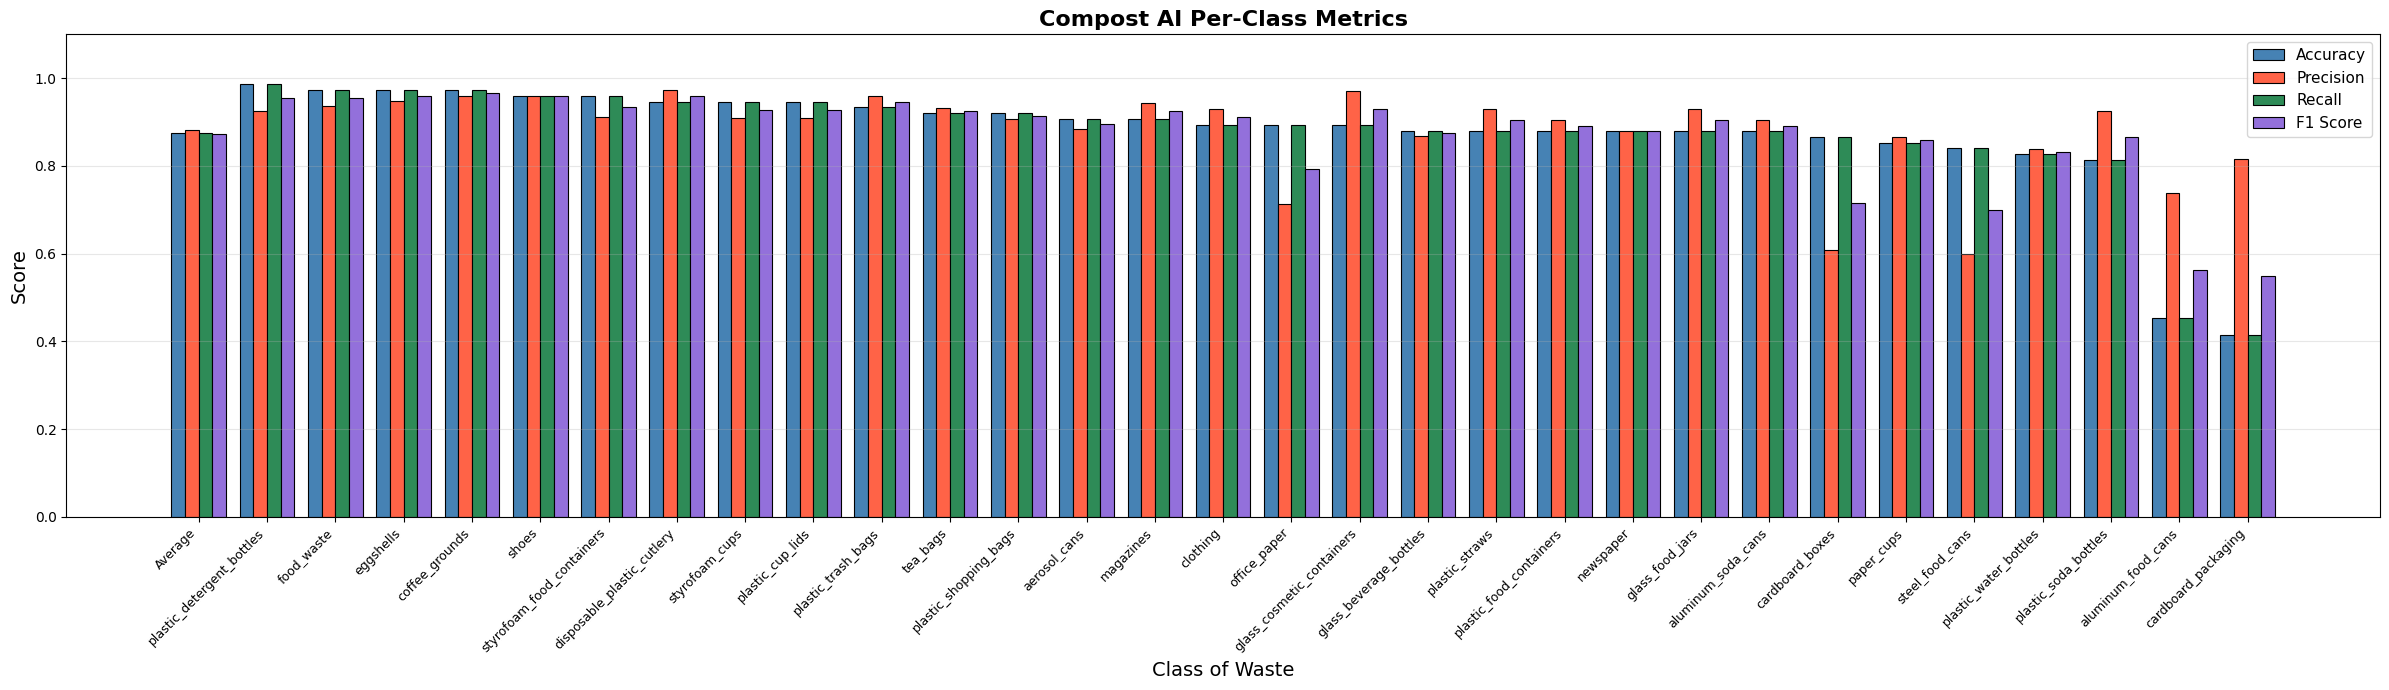


Overall Metrics
Accuracy:  0.8760
Precision: 0.8827
Recall:    0.8760
F1 Score:  0.8739


In [27]:
#==============
# Bar Chart View
#==============
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate per-class metrics
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

# Calculate macro averages
avg_accuracy  = np.mean(per_class_accuracy)
avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
avg_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
avg_f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# Sort classes by descending accuracy with the average bar pinned to the front
sorted_labels    = ['Average'] + [class_names[i] for i in sorted_indices]
sorted_accuracy  = [avg_accuracy]  + [per_class_accuracy[i]  for i in sorted_indices]
sorted_precision = [avg_precision] + [per_class_precision[i] for i in sorted_indices]
sorted_recall    = [avg_recall]    + [per_class_recall[i]    for i in sorted_indices]
sorted_f1        = [avg_f1]        + [per_class_f1[i]        for i in sorted_indices]
x     = np.arange(len(sorted_labels))
width = 0.2

# Plot grouped bar chart with one bar per metric per class
fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x - 1.5*width, sorted_accuracy,  width, label='Accuracy',  color='steelblue',    edgecolor='black', linewidth=0.8)
ax.bar(x - 0.5*width, sorted_precision, width, label='Precision', color='tomato',       edgecolor='black', linewidth=0.8)
ax.bar(x + 0.5*width, sorted_recall,    width, label='Recall',    color='seagreen',     edgecolor='black', linewidth=0.8)
ax.bar(x + 1.5*width, sorted_f1,        width, label='F1 Score',  color='mediumpurple', edgecolor='black', linewidth=0.8)
ax.set_title('Compost AI Per-Class Metrics', fontsize=16, fontweight='bold')
ax.set_xlabel('Class of Waste', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall metric summary
print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {avg_f1:.4f}")

### 3.3 Plot Confusion Matrices
To better understand where the model is failing, we will plot two confusion matrices:

1. A **30-class confusion matrix** that shows which classes the model confuses with which other classes. Most off-diagonal mass is expected to land inside disposal-pathway clusters (one type of paper confused for another type of paper, one type of metal can confused for another), which is much less harmful than a cross-pathway mistake.
2. A **disposal-pathway confusion matrix** that collapses the 30-class predictions down to the four disposal pathways. This is the matrix that matters most for our user-facing decision because it shows whether the model picks the right bin, even when it gets the specific class slightly wrong.

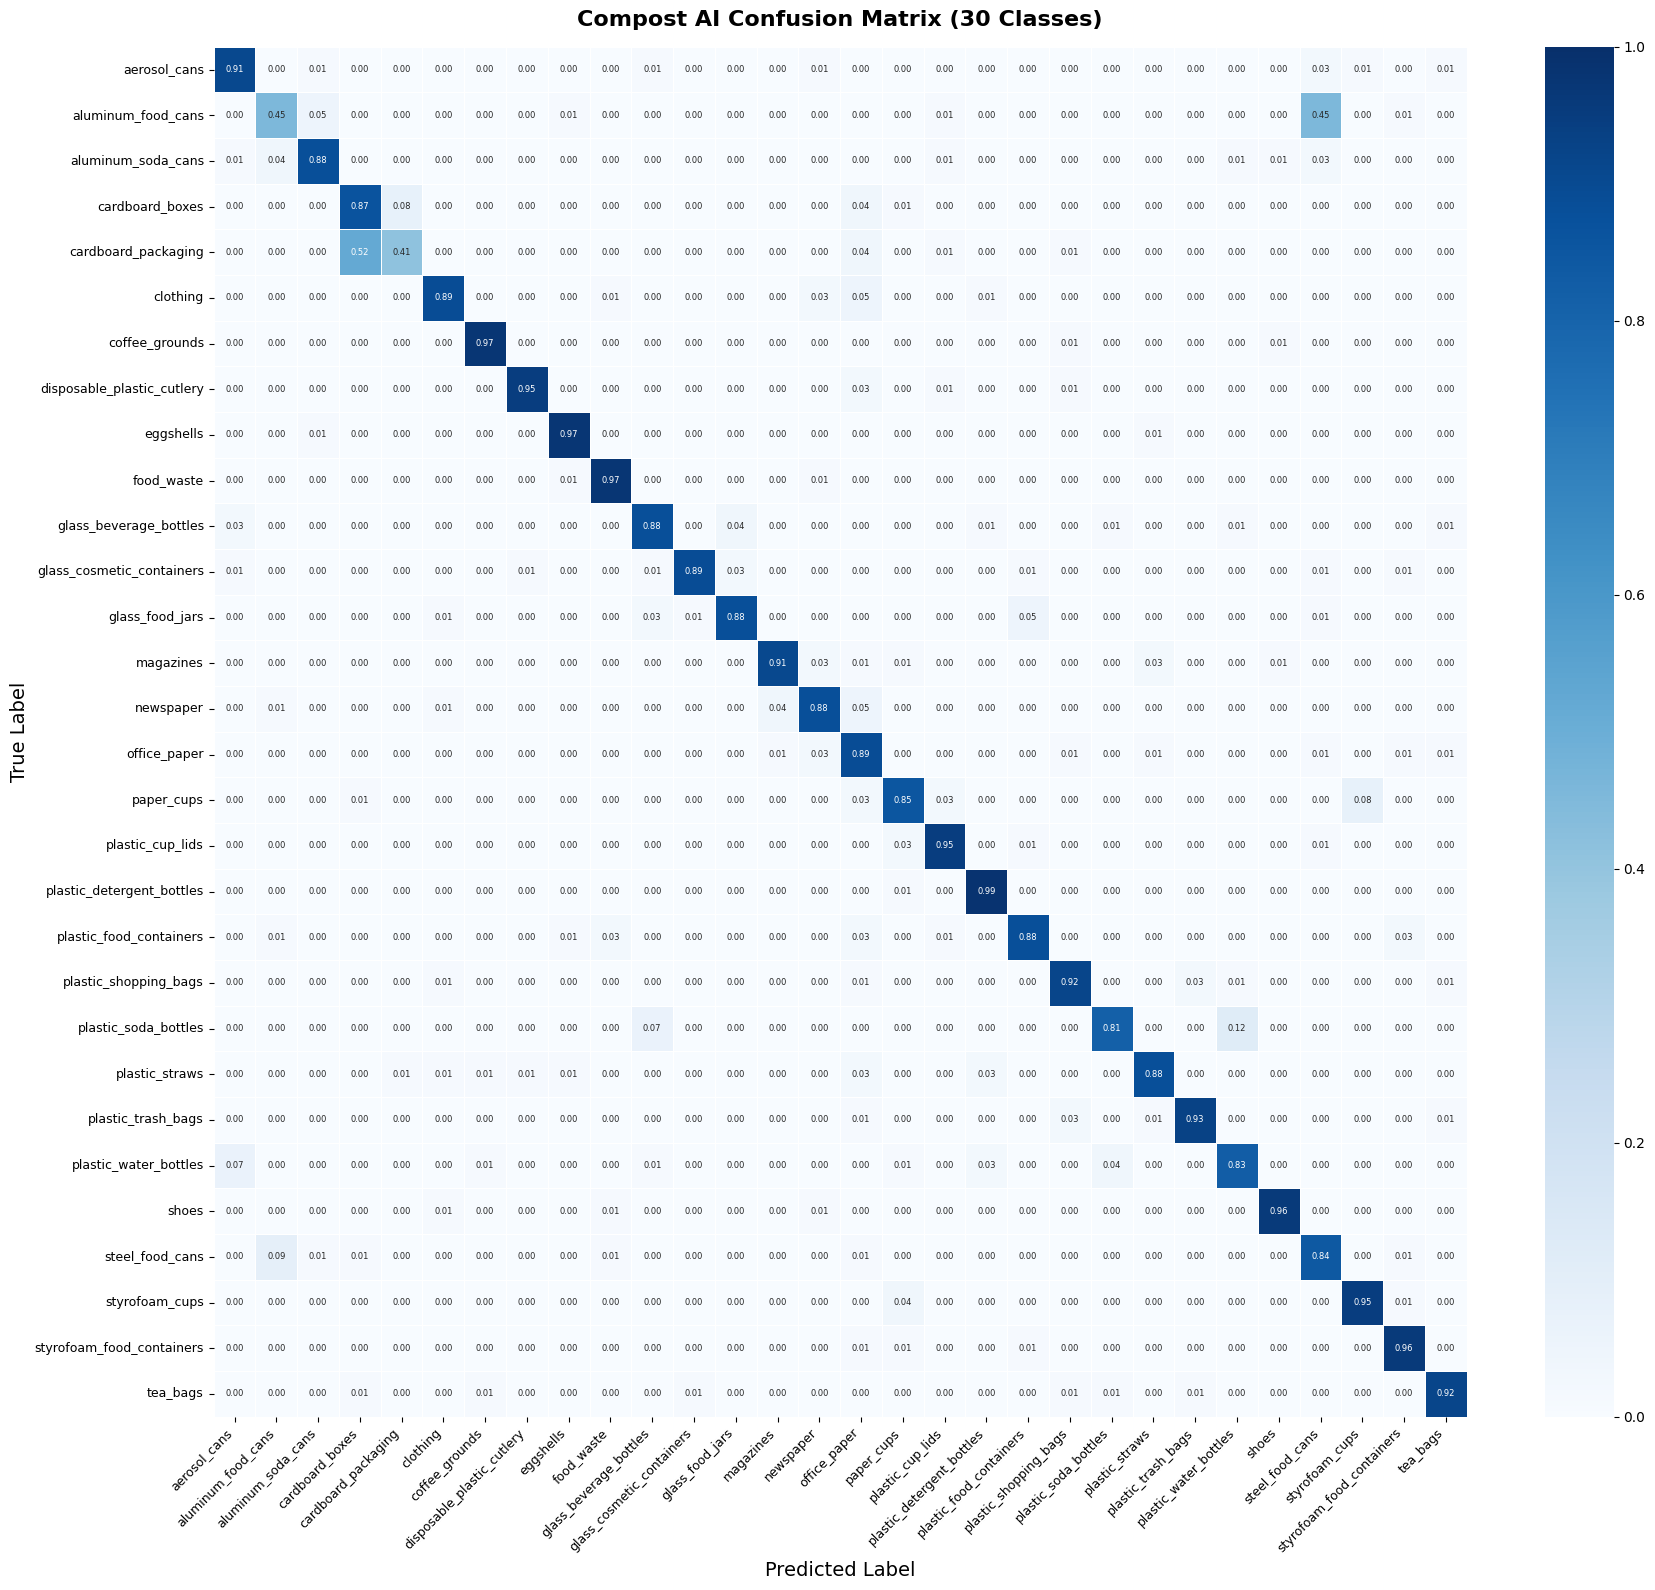

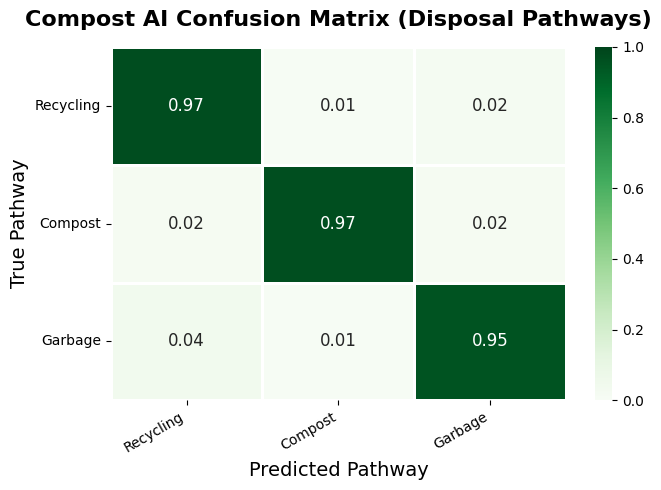

In [30]:
#=============================
# Class-level Confusion Matrix
#=============================

# Normalize so each row sums to 1, making colors comparable across classes regardless of support count
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 6},
    vmin=0,
    vmax=1
)
ax.set_title('Compost AI Confusion Matrix (30 Classes)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'confusion_matrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()

#==================================
# Disposal Pathway Confusion Matrix
#==================================

# Collapse 30-class predictions down to 3 disposal pathways using DISPOSAL_MAP
PATHWAY_ORDER  = ['recycling', 'compost', 'garbage']
PATHWAY_LABELS = [p.title() for p in PATHWAY_ORDER]
pathway_true = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_labels]
pathway_pred = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_preds]
cm_pathway      = confusion_matrix(pathway_true, pathway_pred, labels=PATHWAY_ORDER)
cm_pathway_norm = cm_pathway.astype(float) / cm_pathway.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_pathway_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=PATHWAY_LABELS,
    yticklabels=PATHWAY_LABELS,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 12},
    vmin=0,
    vmax=1
)
ax.set_title('Compost AI Confusion Matrix (Disposal Pathways)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Pathway', fontsize=14)
ax.set_ylabel('True Pathway', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'confusion_matrix_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Plot Pathway Adjusted Accuracy Bar Chart
Adjusted accuracy counts a prediction as correct if the predicted class and the true class map to the same disposal pathway, even when they are different classes. For example, if the model labels a `plastic_soda_bottle` as a `plastic_water_bottle`, both classes map to `curbside_recycling`, so the user still ends up putting the item in the right bin and the prediction counts as correct. This is the metric that matches what our users actually care about: *did the item end up in the right bin?*

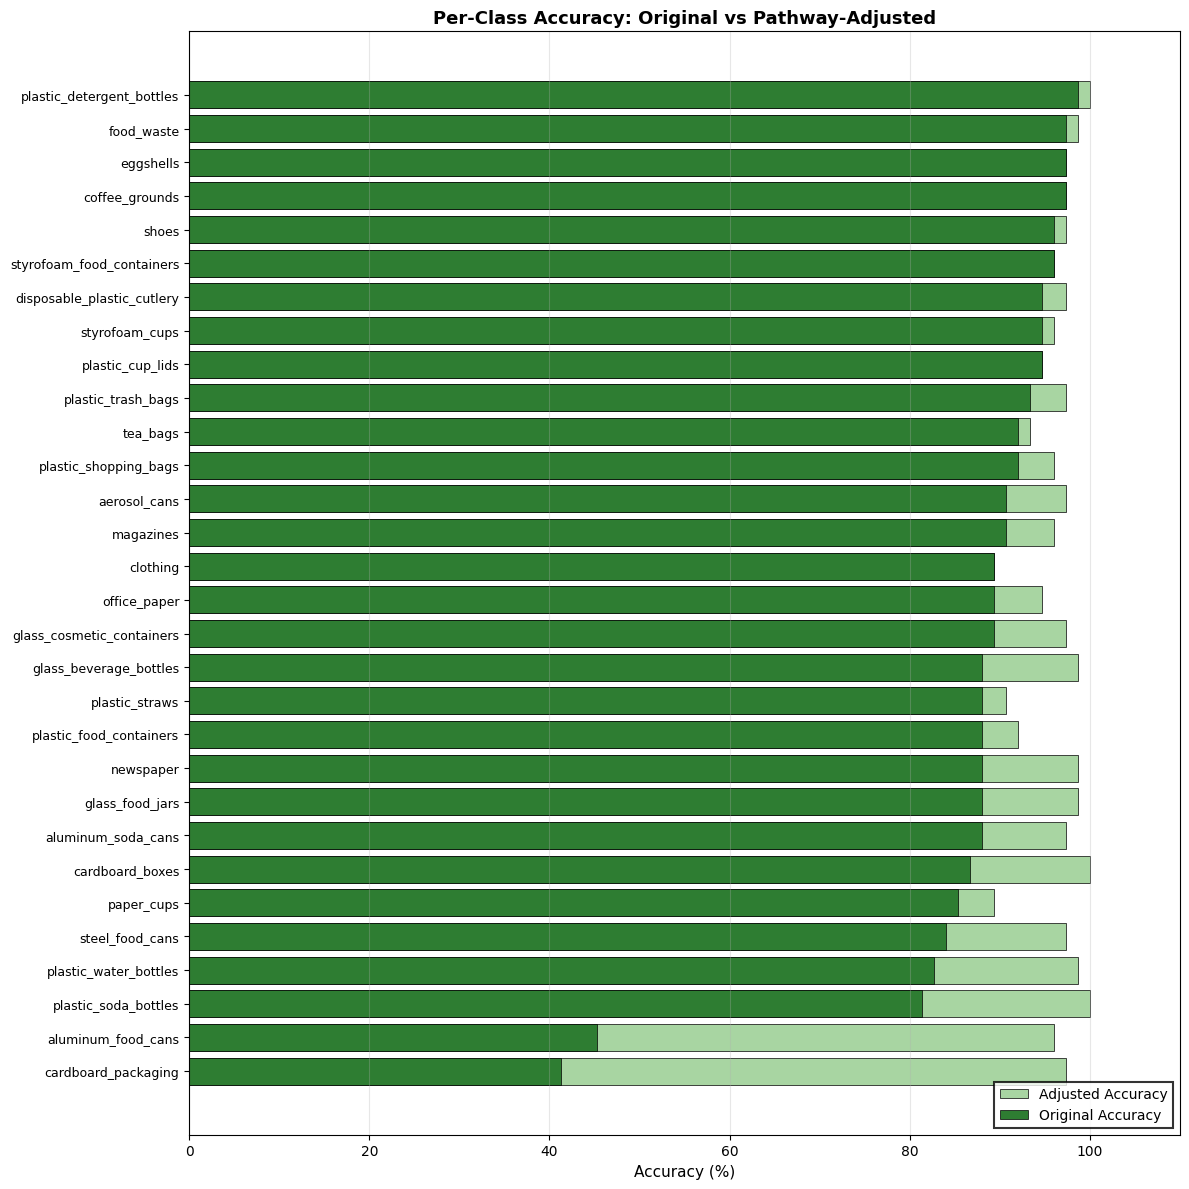

Original Accuracy: 0.8760
Adjusted Accuracy: 0.9636
Pathway Gain:      +0.0876


In [31]:
#===============================
# Adjusted Accuracy Calculation
#===============================

adjusted_correct = np.zeros(NUM_CLASSES)
class_counts     = np.zeros(NUM_CLASSES)
for true_idx, pred_idx in zip(all_labels, all_preds):
    true_pathway = DISPOSAL_MAP.get(class_names[true_idx], 'UNMAPPED')
    pred_pathway = DISPOSAL_MAP.get(class_names[pred_idx], 'UNMAPPED')
    class_counts[true_idx] += 1
    if true_pathway == pred_pathway:
        adjusted_correct[true_idx] += 1
adj_acc_per_class = adjusted_correct / class_counts

#================
# Bar Chart View
#================

# Sort by original accuracy ascending so highest performers sit at the top
sort_idx     = np.argsort(per_class_accuracy)
sorted_names = [class_names[i] for i in sort_idx]
sorted_orig  = [per_class_accuracy[i] * 100 for i in sort_idx]
sorted_adj   = [adj_acc_per_class[i]  * 100 for i in sort_idx]
y = np.arange(len(sorted_names))
fig, ax = plt.subplots(figsize=(12, 12))

# Draw adjusted accuracy bars first so the darker original bars sit on top
ax.barh(y, sorted_adj,  color='#A8D5A2', label='Adjusted Accuracy', edgecolor='black', linewidth=0.5)
ax.barh(y, sorted_orig, color='#2E7D32', label='Original Accuracy', edgecolor='black', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy: Original vs Pathway-Adjusted', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
legend = ax.legend(
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fancybox=False,
    fontsize=10
)
legend.get_frame().set_linewidth(1.5)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'adjusted_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall accuracy comparison
overall_orig = per_class_accuracy.mean()
overall_adj  = adjusted_correct.sum() / class_counts.sum()
print(f"Original Accuracy: {overall_orig:.4f}")
print(f"Adjusted Accuracy: {overall_adj:.4f}")
print(f"Pathway Gain:      {overall_adj - overall_orig:+.4f}")

## 4. Quantize Model and Save Weights
### 4.1 Convert Model into TFLite
We have finished training our model and evaluated its results. However, there is one problem. We cannot deploy this model onto the Raspberry Pi becuase it has too many parameters. To solve this we will use a technique called **quantization**, where we will compress the models file size into a .tflite format, so it can run on the Raspberry Pi 4

In [32]:
# Convert to TFlite with INT 8 Quantization
def representative_dataset():
    for images, _ in train_ds.unbatch().batch(1).take(200):
        yield [tf.cast(images, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS,  # Fallback for any ops that don't support INT8
]
tflite_model = converter.convert()

# Save the TFLite model to disk
TFLITE_PATH = MODELS_PATH / 'compost_ai.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f"Saved to:   {TFLITE_PATH}")
print(f"Model size: {len(tflite_model) / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpmau_3wxi/assets


INFO:tensorflow:Assets written to: /tmp/tmpmau_3wxi/assets


Saved artifact at '/tmp/tmpmau_3wxi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  134409083814160: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134409083813968: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134409077245520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077245328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077246672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077246288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077246096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077247824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077243984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134409077248016: TensorSpec(shape=(), dtype=tf.resource, name=None

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781646651.907048      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781646651.907095      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1781646652.134458      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


Saved to:   /kaggle/working/models/compost_ai.tflite
Model size: 5.01 MB


### 4.2 Evaluate the TFlite Model
We will evaluate the TFlite model on the helf-out test set again to observe how compressing the model's file size changes it's accuracy. 

Keras accuracy:     0.8760
TFLite accuracy:    0.7969
Quantization delta: -0.0791


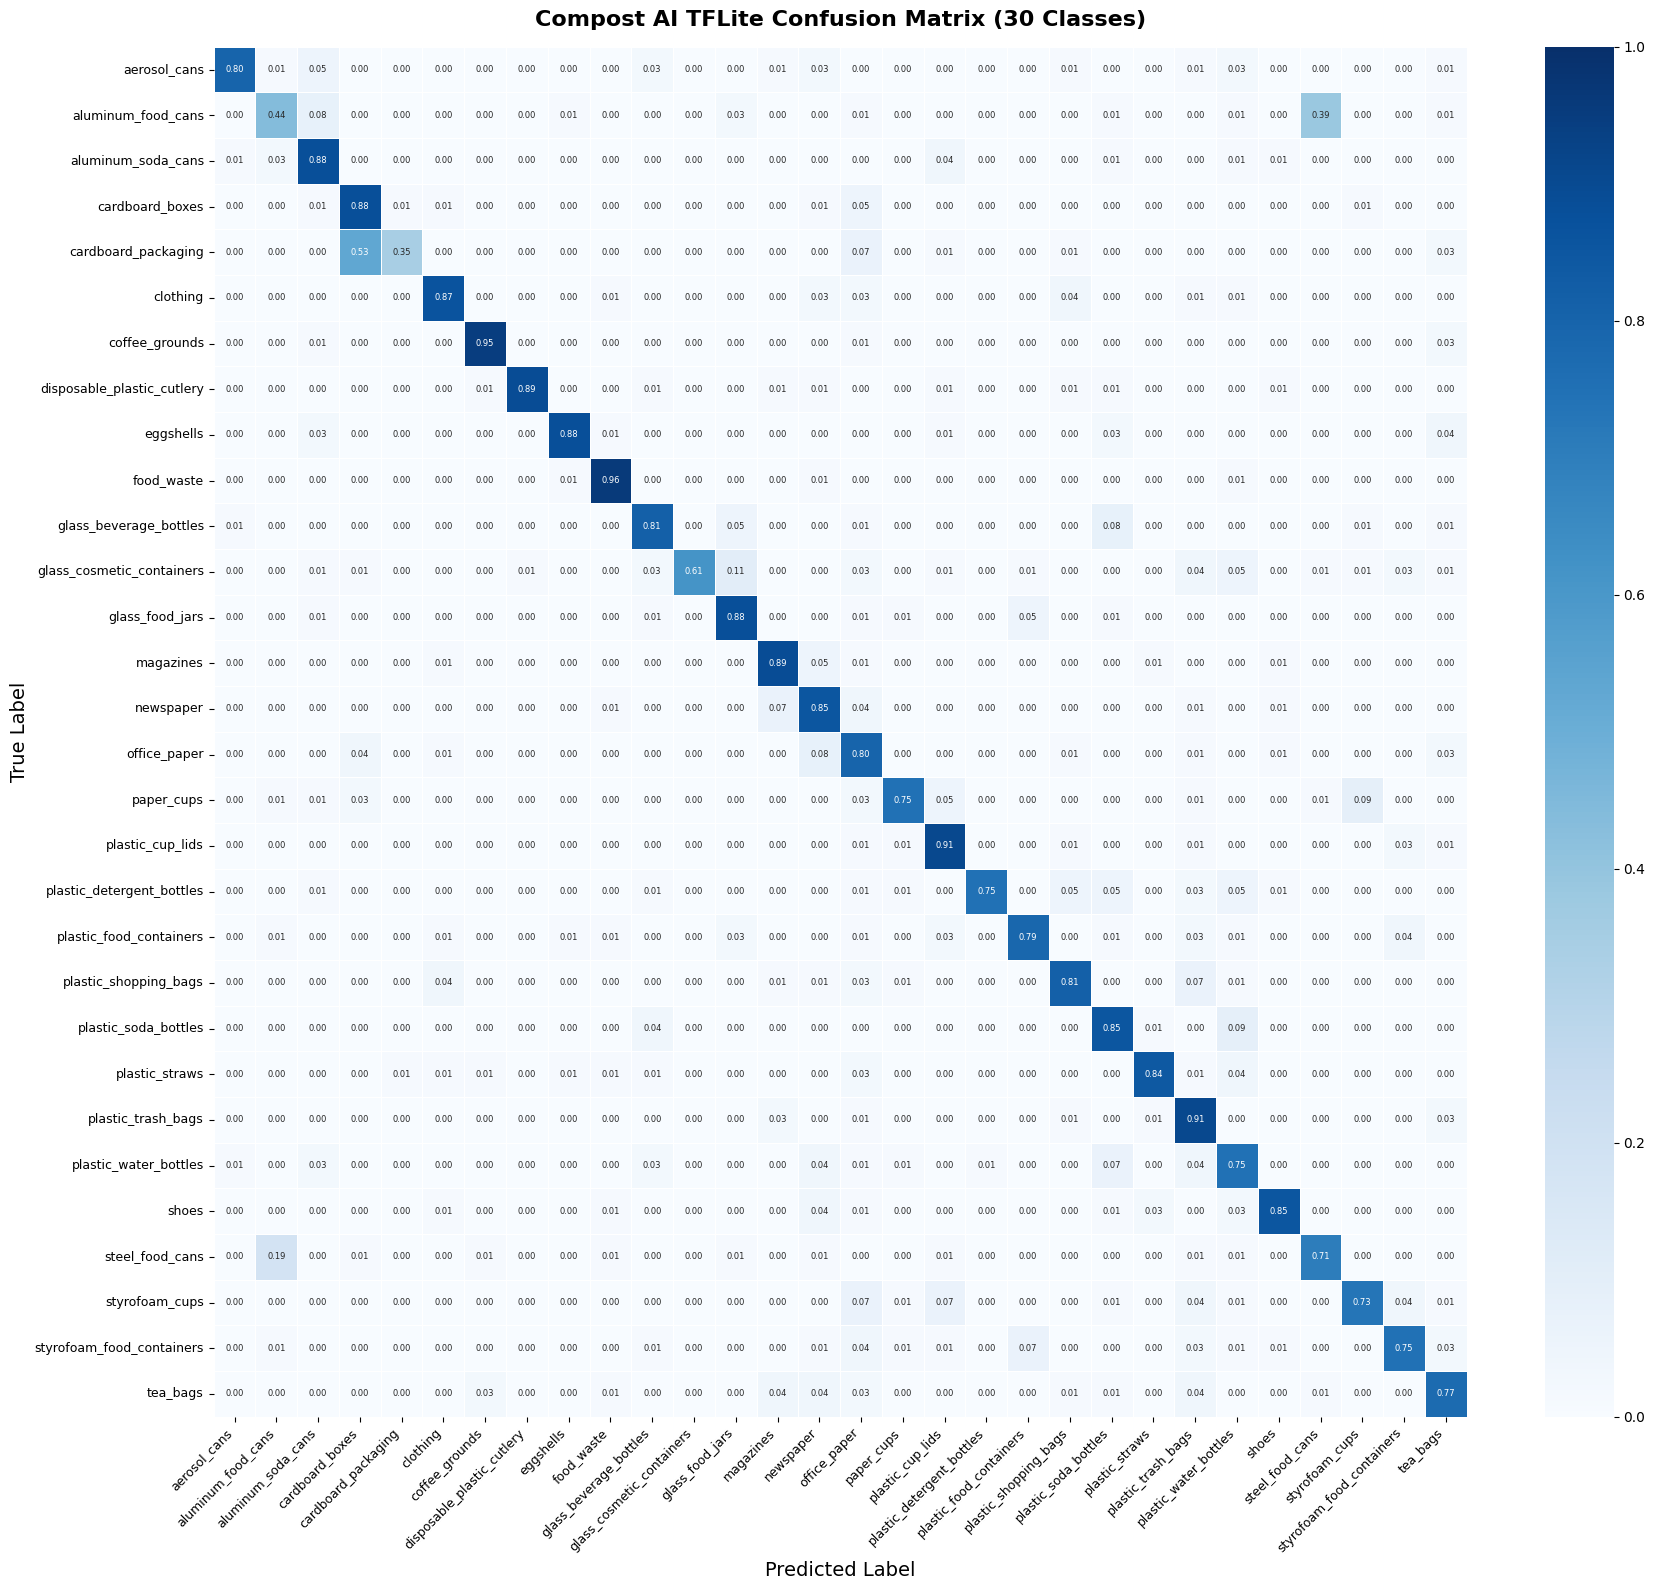

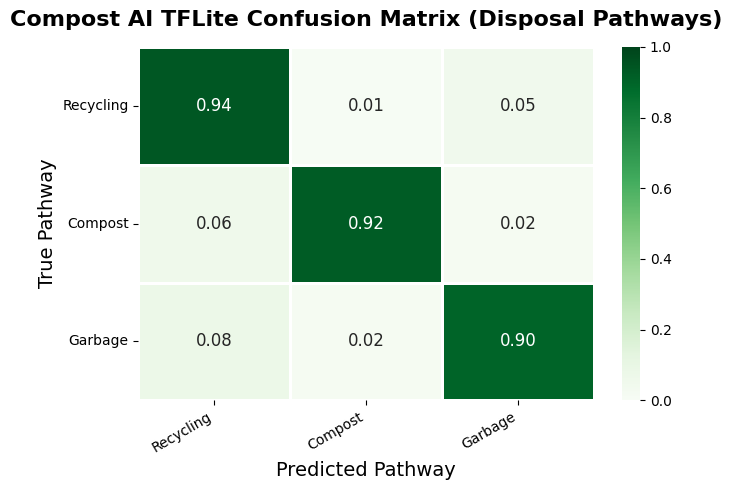

In [34]:
# Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_PATH))
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run predictions on the test set one image at a time through the TFLite interpreter
tflite_preds, tflite_labels = [], []
for images, labels in test_ds.unbatch().batch(1):
    interpreter.set_tensor(input_details[0]['index'], tf.cast(images, tf.float32).numpy())
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    tflite_preds.append(np.argmax(output))
    tflite_labels.append(np.argmax(labels.numpy()))
tflite_preds  = np.array(tflite_preds)
tflite_labels = np.array(tflite_labels)

# Compare TFLite accuracy against the original Keras model to measure quantization degradation
keras_accuracy  = np.mean(all_preds    == all_labels)
tflite_accuracy = np.mean(tflite_preds == tflite_labels)
print(f"Keras accuracy:     {keras_accuracy:.4f}")
print(f"TFLite accuracy:    {tflite_accuracy:.4f}")
print(f"Quantization delta: {tflite_accuracy - keras_accuracy:+.4f}")


# Class-level Confusion Matrix
cm_tflite      = confusion_matrix(tflite_labels, tflite_preds)
cm_tflite_norm = cm_tflite.astype(float) / cm_tflite.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_tflite_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 6},
    vmin=0,
    vmax=1
)
ax.set_title('Compost AI TFLite Confusion Matrix (30 Classes)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'tflite_confusion_matrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()


# Collapse 30-class TFLite predictions down to 3 disposal pathways using DISPOSAL_MAP
PATHWAY_ORDER  = ['recycling', 'compost', 'garbage']
PATHWAY_LABELS = [p.title() for p in PATHWAY_ORDER]
tflite_pathway_true = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in tflite_labels]
tflite_pathway_pred = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in tflite_preds]
cm_pathway      = confusion_matrix(tflite_pathway_true, tflite_pathway_pred, labels=PATHWAY_ORDER)
cm_pathway_norm = cm_pathway.astype(float) / cm_pathway.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_pathway_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=PATHWAY_LABELS,
    yticklabels=PATHWAY_LABELS,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 12},
    vmin=0,
    vmax=1
)
ax.set_title('Compost AI TFLite Confusion Matrix (Disposal Pathways)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Pathway', fontsize=14)
ax.set_ylabel('True Pathway', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'tflite_confusion_matrix_pathways.png', dpi=150, bbox_inches='tight')
plt.show()